# Machine Learning Lab 5 — Linear Regression

## Student Information

**Name:** Muhammad Umar  
**Student ID:** 023-24-0260 
**Section:** H  
**GitHub:** https://github.com/muhammadumarofficial  
**Kaggle:** https://www.kaggle.com/mohdumar10   

## 1. Problem Definition

The goal of this lab is to predict the selling price of houses using Multiple Linear Regression. The target variable is `SalePrice`.

This is a regression problem because `SalePrice` is a continuous numerical value. Therefore, the model will be evaluated using regression metrics such as MAE, MSE, RMSE and R².

## 2. Dataset Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [3]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The training data contains 1,460 houses and 81 columns including the target. The test data contains 1,459 houses and does not contain `SalePrice`. The data contains both numerical and categorical variables.

## 3. Feature and Target Identification

In [ ]:
features = [ "GrLivArea",  "OverallQual",  "TotalBsmtSF", "GarageCars",  "YearBuilt", "FullBath", "Neighborhood", "HouseStyle",  "KitchenQual", "GarageArea", "1stFlrSF"
]

target = "SalePrice"

num_features = []
cat_features = []

for col in features:
    if train[col].dtype == "object":
        cat_features.append(col)
    else:
        num_features.append(col)

print("Dependent variable:", target)
print("Numerical independent variables:", num_features)
print("Categorical independent variables:", cat_features)

Dependent variable: SalePrice
Numerical independent variables: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'GarageArea', '1stFlrSF']
Categorical independent variables: ['Neighborhood', 'HouseStyle', 'KitchenQual']


The dependent variable is `SalePrice`. The independent variables are the selected house features listed above. Numerical features contain values such as area, year, quality score and garage capacity, while categorical features describe categories such as neighborhood, house style and kitchen quality.

This is a regression problem because the target is a continuous price rather than a class label. Therefore, metrics such as MAE, MSE, RMSE and R² are more suitable than classification metrics such as accuracy.

## 4. Data Preparation

The numerical columns are filled with their training median when a value is missing. The categorical columns are filled with their training mode. The categorical variables are converted to numeric values using one-hot encoding. `drop_first=True` removes one reference category from each categorical variable and avoids unnecessary duplicate information.

In [5]:
x = train[features].copy()
y = train[target].copy()

test_x = test[features].copy()

for col in num_features:
    value = x[col].median()
    x[col] = x[col].fillna(value)
    test_x[col] = test_x[col].fillna(value)

for col in cat_features:
    value = x[col].mode()[0]
    x[col] = x[col].fillna(value)
    test_x[col] = test_x[col].fillna(value)

all_x = pd.concat([x, test_x], axis=0)

all_x = pd.get_dummies(
    all_x,
    columns=cat_features,
    drop_first=True,
    dtype=int
)

x = all_x.iloc[:len(train), :]
test_x = all_x.iloc[len(train):, :]

print("Missing values:", x.isnull().sum().sum())
print("All columns numeric:", x.select_dtypes(exclude="number").shape[1] == 0)
print("X shape:", x.shape)

Missing values: 0
All columns numeric: True
X shape: (1460, 42)


The prepared feature data is fully numeric and has no missing values, so it can be used by `LinearRegression`.

## 5. Train/Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("X train shape:", x_train.shape)
print("X test shape:", x_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (1168, 42)
X test shape: (292, 42)
y train shape: (1168,)
y test shape: (292,)


An 80/20 split is used. The model is trained on 80% of the labeled data and tested on the remaining 20% that it did not see during training.

## 6. Linear Regression Model

In [7]:
model = LinearRegression()

model.fit(x_train, y_train)

print("Model trained successfully")

Model trained successfully


## 7. Predictions

In [8]:
y_pred = model.predict(x_test)

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,154500,138672.599197
1,325000,323302.912596
2,115000,113402.876873
3,159000,175295.923686
4,315500,317235.493713
5,75500,68057.354354
6,311500,234614.749188
7,146000,144773.829430
8,84500,67650.271315
9,135500,117523.023718


The table compares the actual house price with the price predicted by the Linear Regression model for 10 test houses.

## 8. Coefficients and Intercept

In [9]:
print("Intercept:", model.intercept_)

coef_table = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

reference = {}

for col in cat_features:
    reference[col] = sorted(train[col].dropna().unique())[0]

interpretation = []

for feature in coef_table["Feature"]:
    coefficient = coef_table.loc[coef_table["Feature"] == feature, "Coefficient"].iloc[0]

    if feature in num_features:
        text = "One unit increase in " + feature + " is associated with a change of about $" + f"{coefficient:,.2f}" + " in predicted price, holding other features constant."
    else:
        main = feature.split("_")[0]
        category = feature[len(main) + 1:]
        text = "Compared with the reference category " + reference[main] + ", " + category + " is associated with a change of about $" + f"{coefficient:,.2f}" + " in predicted price, holding other features constant."

    interpretation.append(text)

coef_table["Interpretation"] = interpretation
coef_table

Intercept: -394548.38050498534


,Feature,Coefficient,Interpretation
0,GrLivArea,69.622452,One unit increase in GrLivArea is associated w...
1,OverallQual,13020.693586,One unit increase in OverallQual is associated...
2,TotalBsmtSF,11.556286,One unit increase in TotalBsmtSF is associated...
3,GarageCars,9815.474730,One unit increase in GarageCars is associated ...
4,YearBuilt,203.541519,One unit increase in YearBuilt is associated w...
5,FullBath,-53.833055,One unit increase in FullBath is associated wi...
6,GarageArea,6.896131,One unit increase in GarageArea is associated ...
7,1stFlrSF,-23.284360,One unit increase in 1stFlrSF is associated wi...
8,Neighborhood_Blueste,1627.494900,"Compared with the reference category Blmngtn, ..."
9,Neighborhood_BrDale,989.747091,"Compared with the reference category Blmngtn, ..."


The intercept is the predicted price when all encoded feature values are zero. In this dataset, that situation does not represent a realistic house, so the intercept does not have a useful direct real-world meaning by itself.

Each coefficient shows the estimated change in predicted price while the other model features are kept constant. For categorical variables, the coefficient is interpreted relative to the reference category.

## 9. Residual Analysis

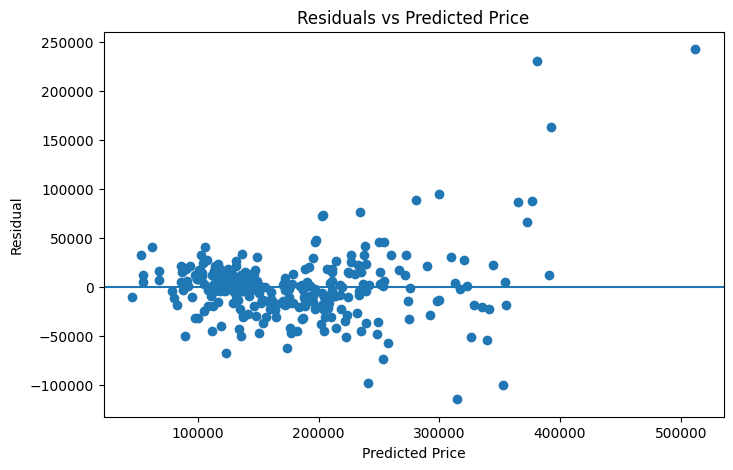

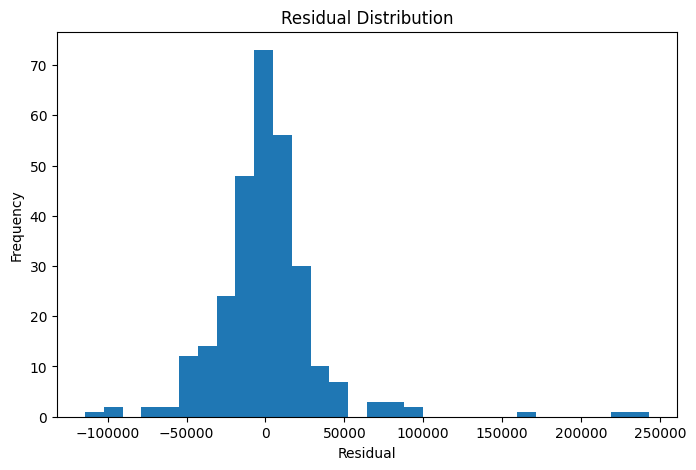

Residual and predicted value correlation: -0.046805828716957015


In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

print("Residual and predicted value correlation:", residuals.corr(pd.Series(y_pred)))

The residuals are spread around zero, but they are not perfectly random across the full prediction range. The residual correlation with predicted values is about 0.205, which suggests that some systematic pattern remains. This means Linear Regression captures a large part of the relationship, but it does not explain every price difference.

## 10. Regression Metrics

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})

test_metrics

,Metric,Value
0,MAE,2.126436e+04
1,MSE,1.226512e+09
2,RMSE,3.502160e+04
3,R2,8.400964e-01


## 11. Training vs Testing Performance

In [12]:
train_pred = model.predict(x_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [mae, mse, rmse, r2]
})

comparison

,Metric,Training,Testing
0,MAE,2.061963e+04,2.126436e+04
1,MSE,1.052001e+09,1.226512e+09
2,RMSE,3.243456e+04,3.502160e+04
3,R2,8.236245e-01,8.400964e-01


The training and testing results are fairly close. The training R² is about 0.824 and the testing R² is about 0.840. There is no large train-test performance gap in this split, so the actual result does not show a large overfitting problem. The small difference can happen because the model is being evaluated on a particular random test split.

## 12. Model Interpretation

In [13]:
feature_effects = []

for col in features:
    if col in num_features:
        value = abs(coef_table.loc[coef_table["Feature"] == col, "Coefficient"].iloc[0])
    else:
        values = coef_table[coef_table["Feature"].str.startswith(col + "_")]["Coefficient"].abs()
        value = values.max()

    feature_effects.append([col, value])

feature_effects = pd.DataFrame(
    feature_effects,
    columns=["Original Feature", "Largest Absolute Coefficient"]
)

feature_effects = feature_effects.sort_values(
    "Largest Absolute Coefficient",
    ascending=False
)

feature_effects

,Original Feature,Largest Absolute Coefficient
6,Neighborhood,75987.009138
8,KitchenQual,53667.262298
7,HouseStyle,21626.536635
1,OverallQual,13020.693586
3,GarageCars,9815.474730
4,YearBuilt,203.541519
0,GrLivArea,69.622452
5,FullBath,53.833055
10,1stFlrSF,23.284360
2,TotalBsmtSF,11.556286


Based on the coefficient magnitudes, `Neighborhood`, `KitchenQual`, and `HouseStyle` show some of the largest coefficient effects in this model. These results should be interpreted carefully because numerical features and one-hot encoded categories use different scales. A larger coefficient does not automatically mean that a feature is more important than every other feature.

## 14. Kaggle Submission

For the Kaggle submission, the same selected features and encoding are used for `test.csv`. The final model is trained using all available labeled training houses, then predictions are created for every test house. The submission file contains exactly two columns: `Id` and `SalePrice`.

In [14]:
final_model = LinearRegression()

final_model.fit(x, y)

final_pred = final_model.predict(test_x)

submission = sample.copy()
submission["SalePrice"] = final_pred

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
print("Submission columns:", submission.columns.tolist())

submission.head(10)

Submission shape: (1459, 2)
Submission columns: ['Id', 'SalePrice']


,Id,SalePrice
0,1461,115585.954131
1,1462,160232.738501
2,1463,160808.708276
3,1464,179554.178548
4,1465,254680.725914
5,1466,176366.511787
6,1467,168379.140759
7,1468,163479.197425
8,1469,199157.015412
9,1470,111382.649137


The `submission.csv` file has the required `Id` and `SalePrice` columns and contains one prediction for every row in the test dataset.

The model was submitted to the Kaggle House Prices competition.

**Public leaderboard score:** 0.17015  
**Public leaderboard rank:** 2790  

The submission was successfully accepted by Kaggle and received a public score of 0.17015.